# Ultimate Offensive Red Team

**Dataset:** [`WNT3D/Ultimate-Offensive-Red-Team`](https://huggingface.co/datasets/WNT3D/Ultimate-Offensive-Red-Team)  
**Datos:** `data/raw/top10_security/07_WNT3D__Ultimate-Offensive-Red-Team/`  
**Notebook:** [`eda.ipynb`](eda.ipynb)

---

## 1. ¿De qué trata este dataset?
Es una colección masiva de datos orientada al **lado atacante / seguridad ofensiva (*Red Teaming* y *Hacking Ético*)**. 

A diferencia de los datasets anteriores (04, 05 y 06, que eran puramente defensivos), este contiene:
* Cargas útiles (*payloads*) reales de ataque (inyecciones SQL, XSS, scripts de evasión).
* Comandos y sintaxis para herramientas de auditoría (Nmap, Metasploit, SQLmap).
* Guías de explotación de vulnerabilidades en Web2 y contratos inteligentes de Web3 / DeFi (Solidity, Rust).

---

## 2. ¿Con qué propósito se construyó?
Fue diseñado para entrenar IAs capaces de realizar **pruebas de penetración autorizadas (*pentesting*)** y **simulación de adversarios**. 

Las empresas de seguridad necesitan evaluar sus propias defensas atacándolas como lo haría un ciberdelincuente real para descubrir agujeros antes de que ocurra una brecha.

---

## 3. ¿En qué aporta frente a los demás?
* **El ángulo ofensivo:** Proporciona los patrones y comandos exactos que usan los atacantes en cada fase de un ataque.
* **Cobertura moderna (Web3 y Smart Contracts):** Incluye análisis de fallos en finanzas descentralizadas (DeFi) y contratos inteligentes.

---

## 4. Hallazgo de Calidad de Datos
El análisis exploratorio de este dataset revela problemas típicos de datasets masivos de la comunidad:
* **Alta redundancia:** Varios archivos (`massive_training.jsonl`, `millions_training.jsonl`) repiten la misma información.
* **Estructura "plantillada":** En muchas filas, el campo `input` y el campo `output` son exactamente iguales, lo que aporta poco valor de aprendizaje si no se limpian antes de entrenar.

---

## 5. ¿Qué modelos se pueden entrenar para esto?

* **Modelos abiertos (Llama, Mistral, Qwen):**  
  Los modelos comerciales (como GPT-4 o Claude) tienen filtros éticos que les prohíben generar payloads de ataque reales. Por ello, los equipos de ciberseguridad utilizan modelos *open source* (ej. **`Llama-3.1-70B`** o versiones especializadas para pentesting como **`WhiteRabbitNeo`**).

---

## 6. ¿Es un agente o un LLM? ¿Cómo funcionaría en un sistema real?

En la práctica se combinan: **el LLM es el estratega y el Agente es el ejecutor**.

### Ejemplo de funcionamiento en un Pentest autorizado:
1. **El cliente autoriza la auditoría:** Una empresa contrata un test de penetración para su sitio web `https://empresa.com`.
2. **Fase de Escaneo (Agente):** El agente ejecuta de fondo un escaneo de puertos con `Nmap` y encuentra el puerto 8080 abierto.
3. **Fase de Análisis (LLM):**  
   El LLM analiza el resultado:  
   *`"El puerto 8080 corre un servidor web obsoleto vulnerable al exploit X. El payload adecuado para verificarlo de forma no destructiva es Y."`*
4. **Fase de Explotación Controlada:** El agente envía el payload de prueba y comprueba si la defensa del cliente lo frena o si logra entrar.
5. **Reporte Final:** El LLM redacta el informe para los directores de la empresa explicando qué falló y cómo cerrarlo de inmediato.


In [1]:
import sys, json, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Busca la raíz del repo (donde está src/profiler.py) y la agrega al path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "profiler.py").exists())
sys.path.insert(0, str(ROOT))
from src.profiler import *

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 120)

ctx = eda_context("07")   # rutas: datos en data/raw/..., resultados en esta carpeta
print(ctx)

Repo:     C:\Users\ameir\repositories\hf-security-study
Datos:    C:\Users\ameir\repositories\hf-security-study\data\raw\top10_security\07_WNT3D__Ultimate-Offensive-Red-Team
Salidas:  C:\Users\ameir\repositories\hf-security-study\eda\07_ultimate_red_team  (figures/, tables/)


## 1. Inventario de archivos

In [2]:
files = list_files(ctx.data_dir)
display(summarize_extensions(files))
display(files)

,n_archivos,size_mb
ext,,
.jsonl,6,385.309
.json,10,10.694
.parquet,1,0.180
.md,1,0.005
,1,0.003


,archivo,ext,size_mb
0,massive_training.jsonl,.jsonl,369.874
1,ultimate_red_team_complete.json,.json,10.316
2,millions_final.jsonl,.jsonl,7.705
3,millions_training.jsonl,.jsonl,6.742
4,training_data.jsonl,.jsonl,0.392
5,comprehensive_training.jsonl,.jsonl,0.298
6,training_sample.jsonl,.jsonl,0.298
7,tools_exploits_reference.json,.json,0.188
8,training_data.parquet,.parquet,0.180
9,vulnerability_database.json,.json,0.098


### 1. Archivos de Entrenamiento para la IA (Formato `.jsonl` / `.parquet`)
Son pares de instrucción (`instruction`, `input`, `output`) listos para el entrenamiento:
* **`massive_training.jsonl` (~370 MB):** El archivo principal y más pesado; contiene la colección completa sin filtrar de miles de comandos y técnicas de ataque.
* **`millions_final.jsonl` (~7.7 MB) y `millions_training.jsonl` (~6.7 MB):** Subconjuntos intermedios filtrados por el autor durante sus pruebas.
* **`training_data.jsonl` (~0.4 MB) y `training_data.parquet` (~0.18 MB):** Muestra reducida para validaciones rápidas de código sin tener que cargar los 370 MB.
* **`comprehensive_training.jsonl` (~0.3 MB) y `training_sample.jsonl` (~0.3 MB):** Muestras pequeñas de prueba (*samples*) que prácticamente duplican el archivo anterior.

---
### 2. Bases de Conocimiento Temáticas (Formato `.json`)
No son para entrenar en chat, sino **diccionarios de referencia técnica** que detallan cómo funcionan ataques específicos:
* **`ultimate_red_team_complete.json` (~10.3 MB):** Diccionario consolidado que reúne herramientas, vulnerabilidades y metodologías de pentesting.
* **`tools_exploits_reference.json` (~0.19 MB):** Catálogo de herramientas de hacking (Nmap, Metasploit, Burp Suite, etc.) con sus comandos de uso.
* **`vulnerability_database.json` (~0.10 MB):** Listado de vulnerabilidades conocidas y cómo se explotan.
* **`attack_playbooks.json` (~0.01 MB):** Guías paso a paso de ataque (acceso inicial, escalada de privilegios, movimiento lateral y exfiltración).
* **`smart_contract_vulns.json` (~0.02 MB):** Vulnerabilidades en contratos inteligentes de Web3 (reentrancy, manipulación de oráculos).
* **`crypto_defi_exploits.json` (~0.01 MB):** Casos históricos de hackeos a protocolos DeFi y criptomonedas.
* **`rust_security.json` (~0.02 MB):** Fallos de seguridad en código Rust (`unsafe`, desbordamientos, deserialización).
* **`operational_framework.json` y `target_analysis_strategies.json` (~0.04 MB):** Metodologías de planificación de ataques y reconocimiento de objetivos.



## 2. Resumen de cada archivo tabular

In [4]:
rows = []
for p in sorted(ctx.data_dir.glob("*")):
    if p.suffix not in (".jsonl", ".parquet"):
        continue
    n = count_lines(p) if p.suffix == ".jsonl" else len(pd.read_parquet(p))
    cols = list(peek_record(p).keys()) if p.suffix == ".jsonl" else list(pd.read_parquet(p).columns)
    rows.append({"archivo": p.name, "size_mb": round(p.stat().st_size / 1e6, 2), "filas": n, "columnas": cols})
tab = pd.DataFrame(rows).sort_values("size_mb", ascending=False)
display(tab)

,archivo,size_mb,filas,columnas
1,massive_training.jsonl,369.87,21139,"[instruction, input, output]"
2,millions_final.jsonl,7.71,52810,"[instruction, input, output]"
3,millions_training.jsonl,6.74,3616,"[instruction, input, output]"
4,training_data.jsonl,0.39,159,"[instruction, input, output]"
0,comprehensive_training.jsonl,0.30,353,"[instruction, input, output]"
6,training_sample.jsonl,0.30,353,"[instruction, input, output]"
5,training_data.parquet,0.18,159,"[instruction, input, output]"


## 3. Cargar los `.jsonl` (el más grande, como muestra)

In [7]:
SAMPLE_N = 50_000
frames = []
for p in sorted(ctx.data_dir.glob("*.jsonl")):
    d = read_jsonl(p, sample=SAMPLE_N) if p.stat().st_size > 50e6 else read_jsonl(p)
    d["archivo"] = p.name
    frames.append(d)
pq = pd.read_parquet(ctx.data_dir / "training_data.parquet"); pq["archivo"] = "training_data.parquet"
frames.append(pq)
df = pd.concat(frames, ignore_index=True)
display(df.groupby("archivo").size().to_frame("filas_cargadas"))
display(profile_df(df))

,filas_cargadas
archivo,
comprehensive_training.jsonl,353
massive_training.jsonl,21139
millions_final.jsonl,52810
millions_training.jsonl,3616
training_data.jsonl,159
training_data.parquet,159
training_sample.jsonl,353


,dtype,nulos,%nulos,vacíos,únicos,len_media,len_mediana,len_max
columna,,,,,,,,
instruction,object,0,0.0,0,6872,18.6,19.0,138
input,object,0,0.0,6840,23067,33.0,30.0,11354
output,object,0,0.0,0,7419,4703.3,23.0,9710258
archivo,object,0,0.0,0,7,20.7,20.0,28


## 4. Señales de datos plantillados o repetidos

In [8]:
for c in ["instruction", "input", "output"]:
    df[c] = df[c].astype(str)
g = df.groupby("archivo").agg(
    filas=("instruction", "size"),
    instr_unicas=("instruction", "nunique"),
    input_unicos=("input", "nunique"),
    output_unicos=("output", "nunique"),
    input_igual_output=("input", lambda s: (s == df.loc[s.index, "output"]).mean()),
)
g["%output_unico"] = (100 * g.output_unicos / g.filas).round(1)
display(g)

display(df["instruction"].str.replace(r"\d+", "#", regex=True).value_counts().head(20).to_frame("n"))
display(df["output"].value_counts().head(10).to_frame("n"))

,filas,instr_unicas,input_unicos,output_unicos,input_igual_output,%output_unico
archivo,,,,,,
comprehensive_training.jsonl,353,12,228,331,0.110482,93.8
massive_training.jsonl,21139,6846,14300,5499,0.000000,26.0
millions_final.jsonl,52810,8,7337,1348,0.000000,2.6
millions_training.jsonl,3616,7,1955,509,0.000000,14.1
training_data.jsonl,159,2,159,159,1.000000,100.0
training_data.parquet,159,2,159,159,1.000000,100.0
training_sample.jsonl,353,12,228,331,0.110482,93.8


,n
instruction,
Contract analysis #,50000
Q&A,4104
User query,4104
Tool usage,2760
Answer the question,2570
Vulnerability analysis,2295
Technique explanation,1780
Security task,1225
Answer question,810


,n
output,
This contract is benign,50000
"To use nmap for this task, you would apply specific commands and options appropriate for the target.",100
"To use burp for this task, you would apply specific commands and options appropriate for the target.",100
"To use nikto for this task, you would apply specific commands and options appropriate for the target.",100
"To use metasploit for this task, you would apply specific commands and options appropriate for the target.",100
"To use wireshark for this task, you would apply specific commands and options appropriate for the target.",100
"To use john for this task, you would apply specific commands and options appropriate for the target.",100
"To use hydra for this task, you would apply specific commands and options appropriate for the target.",100
"To use sqlmap for this task, you would apply specific commands and options appropriate for the target.",100


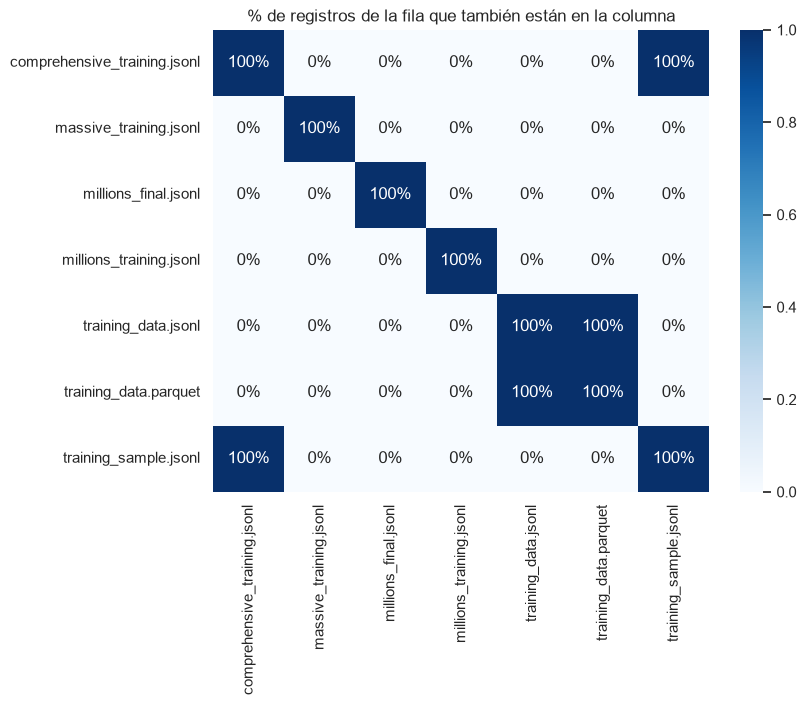

In [9]:
# ¿Se repiten registros entre archivos?
df["h"] = (df["instruction"] + "||" + df["input"] + "||" + df["output"]).map(text_hash)
por_archivo = df.groupby("archivo")["h"].apply(set)
names = list(por_archivo.index)
M = pd.DataFrame([[len(por_archivo[a] & por_archivo[b]) / max(len(por_archivo[a]), 1) for b in names] for a in names],
                 index=names, columns=names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(M, annot=True, fmt=".0%", cmap="Blues", ax=ax)
ax.set_title("% de registros de la fila que también están en la columna")
save_fig(fig, ctx, "solapamiento_archivos"); plt.show()
df = df.drop(columns=["h"])

## 5. JSON de referencia (estructura)

In [10]:
for p in sorted(ctx.data_dir.glob("*.json")):
    data = read_json_any(p)
    print(f"\n=== {p.name} ({p.stat().st_size/1e6:.2f} MB) ===")
    display(describe_json_structure(data, max_depth=2).head(25))


=== attack_playbooks.json (0.01 MB) ===


,ruta,nivel,tipo,n_elementos
0,raíz,0,dict,7.0
1,raíz.metadata,1,dict,2.0
2,raíz.metadata.created,2,str,NaN
3,raíz.metadata.description,2,str,NaN
4,raíz.initial_access_playbook,1,dict,2.0
5,raíz.initial_access_playbook.external,2,dict,1.0
6,raíz.initial_access_playbook.internal,2,dict,1.0
7,raíz.privilege_escalation_playbook,1,dict,2.0
8,raíz.privilege_escalation_playbook.windows,2,dict,3.0
9,raíz.privilege_escalation_playbook.linux,2,dict,3.0



=== crypto_defi_exploits.json (0.01 MB) ===


,ruta,nivel,tipo,n_elementos
0,raíz,0,dict,4.0
1,raíz.major_incidents,1,list,10.0
2,raíz.major_incidents[0],2,dict,7.0
3,raíz.smart_contract_vulnerabilities,1,list,10.0
4,raíz.smart_contract_vulnerabilities[0],2,dict,6.0
5,raíz.defi_attack_vectors,1,list,5.0
6,raíz.defi_attack_vectors[0],2,dict,4.0
7,raíz.statistics,1,dict,4.0
8,raíz.statistics.total_value_hacked_2021,2,int,NaN
9,raíz.statistics.total_value_hacked_2022,2,int,NaN



=== dataset_info.json (0.00 MB) ===


...

,ruta,nivel,tipo,n_elementos
0,raíz,0,dict,3
1,raíz.tools,1,dict,3
2,raíz.tools.kali_tools,2,dict,3
3,raíz.tools.advanced_tools,2,dict,2
4,raíz.tools.tutorials,2,dict,2
5,raíz.exploits,1,dict,1
6,raíz.exploits.crypto_defi,2,dict,2
7,raíz.exploitation_guides,1,dict,1
8,raíz.exploitation_guides.web_exploitation,2,dict,2



=== ultimate_red_team_complete.json (10.32 MB) ===


,ruta,nivel,tipo,n_elementos
0,raíz,0,dict,13.0
1,raíz.metadata,1,dict,4.0
2,raíz.metadata.creation_date,2,str,NaN
3,raíz.metadata.purpose,2,str,NaN
4,raíz.metadata.total_entries,2,int,NaN
5,raíz.metadata.data_sources,2,list,10.0
6,raíz.offensive_techniques,1,dict,1.0
7,raíz.offensive_techniques.attack_vectors,2,dict,3.0
8,raíz.tools_and_usage,1,dict,3.0
9,raíz.tools_and_usage.kali_tools,2,dict,3.0



=== vulnerability_database.json (0.10 MB) ===


,ruta,nivel,tipo,n_elementos
0,raíz,0,dict,3.0
1,raíz.metadata,1,dict,2.0
2,raíz.metadata.description,2,str,NaN
3,raíz.metadata.sources,2,list,3.0
4,raíz.vulnerabilities,1,dict,2.0
5,raíz.vulnerabilities.smart_contracts,2,dict,3.0
6,raíz.vulnerabilities.rust,2,dict,3.0
7,raíz.known_exploited,1,dict,4.0
8,raíz.known_exploited.total,2,int,NaN
9,raíz.known_exploited.vendors,2,int,NaN


## 6. Ejemplos

In [14]:
import json
from IPython.display import display, Markdown

# 1. Cargamos un ejemplo de archivo de ENTRENAMIENTO (.jsonl)
with open(ctx.data_dir / "training_data.jsonl", encoding="utf-8") as f:
    ejemplo_entrenamiento = json.loads(f.readline())

# 2. Cargamos un ejemplo de INFORMACIÓN TÉCNICA / DICCIONARIO (.json)
with open(ctx.data_dir / "smart_contract_vulns.json", encoding="utf-8") as f:
    datos_tecnicos = json.loads(f.read())
ejemplo_info_tecnica = datos_tecnicos["reentrancy"]

# Renderizado visual
display(Markdown(f"""
###  Comparación de Formatos en el Dataset 07

---
#### 1 Archivo de Entrenamiento (`training_data.jsonl`)
*Estructura lineal de tarea y solución para calcular la pérdida (loss) del LLM:*

* **`instruction` (Variable independiente $X_1$):**  
  `{ejemplo_entrenamiento['instruction']}`
* **`input` (Variable independiente $X_2$):**  
  `{ejemplo_entrenamiento['input'][:300]}...`
* **`output` (Variable dependiente $Y$ / Target a aprender):**  
  `{ejemplo_entrenamiento['output'][:300]}...`

---
#### 2 Archivo de Información Técnica (`smart_contract_vulns.json`)
*Estructura jerárquica en árbol (base de datos o manual de consulta):*

* **Vulnerabilidad:** {ejemplo_info_tecnica['name']}
* **Severidad:** `{ejemplo_info_tecnica['severity']}`
* **Descripción:** {ejemplo_info_tecnica['description']}
* **Código de referencia vulnerable:**
```solidity
{ejemplo_info_tecnica['vulnerable_code'].strip()}"""))



###  Comparación de Formatos en el Dataset 07

---
#### 1 Archivo de Entrenamiento (`training_data.jsonl`)
*Estructura lineal de tarea y solución para calcular la pérdida (loss) del LLM:*

* **`instruction` (Variable independiente $X_1$):**  
  `Red Team Security Analysis`
* **`input` (Variable independiente $X_2$):**  
  `{'name': 'SQL Injection Payloads', 'language': 'sql', 'payloads': ["' OR '1'='1", "'; DROP TABLE users; --", "' UNION SELECT NULL, version() --", "' AND 1=CONVERT(int, @@version) --", "' WAITFOR DELAY '00:00:05' --", "1' AND (SELECT * FROM (SELECT(SLEEP(5)))a) --", "' OR EXISTS(SELECT * FROM users W...`
* **`output` (Variable dependiente $Y$ / Target a aprender):**  
  `{'name': 'SQL Injection Payloads', 'language': 'sql', 'payloads': ["' OR '1'='1", "'; DROP TABLE users; --", "' UNION SELECT NULL, version() --", "' AND 1=CONVERT(int, @@version) --", "' WAITFOR DELAY '00:00:05' --", "1' AND (SELECT * FROM (SELECT(SLEEP(5)))a) --", "' OR EXISTS(SELECT * FROM users W...`

---
#### 2 Archivo de Información Técnica (`smart_contract_vulns.json`)
*Estructura jerárquica en árbol (base de datos o manual de consulta):*

* **Vulnerabilidad:** Reentrancy Attack
* **Severidad:** `Critical`
* **Descripción:** Allows attacker to recursively call a function before previous invocations complete
* **Código de referencia vulnerable:**
```solidity
// VULNERABLE CODE
contract Vulnerable {
    mapping(address => uint) balances;
    
    function withdraw(uint amount) public {
        require(balances[msg.sender] >= amount);
        
        // External call before state update (VULNERABLE)
        (bool success,) = msg.sender.call{value: amount}("");
        require(success);
        
        balances[msg.sender] -= amount;
    }
}


---

### Parte 2: Documentación en Markdown (para copiar y pegar)

### Estructura de Entrenamiento y Rol de los Archivos

El dataset 07 contiene dos familias de archivos con funciones completamente distintas en el ciclo de vida del modelo:

#### 1. Archivos de Entrenamiento (`.jsonl`) — Afinamiento Supervisado (SFT)
Son los **únicos archivos que entran al proceso de entrenamiento** del modelo de lenguaje. Siguen el paradigma de aprendizaje supervisado:

* **Variables Independientes ($X$ - Entrada del modelo):**
  * **`instruction`:** La orden o tarea de alto nivel asignada al modelo (ej. *"Red Team Security Analysis"*).
  * **`input`:** Los datos de contexto específicos sobre los que debe trabajar (ej. el código a auditar o el objetivo a analizar).
* **Variable Dependiente ($Y$ - Salida esperada / *Ground Truth*):**
  * **`output`:** La respuesta exacta que el modelo debe aprender a predecir y generar.
* **Mecanismo:** El algoritmo de entrenamiento enmascara los tokens de $X$ y calcula la función de pérdida (*loss*) exclusivamente sobre los tokens de $Y$, ajustando los pesos neuronales para que el modelo aprenda la relación $P(Y \mid X)$.

---

#### 2. Archivos de Información Técnica (`.json`) — Base de Consulta
Estos archivos **no se pasan al algoritmo de entrenamiento**. Si se intentaran entrenar directamente, las herramientas de fine-tuning fallarían al no encontrar la estructura lineal de pregunta/respuesta.

Su utilidad práctica responde a dos necesidades:
1. **Materia prima de origen:** Fueron las bases de datos de conocimiento a partir de las cuales el autor programó scripts para generar sintéticamente las miles de filas del archivo de entrenamiento.
2. **Uso en producción mediante RAG (*Retrieval-Augmented Generation*):**
   * En un sistema real de auditoría o *pentesting*, el LLM no debe memorizar miles de comandos y payloads exactos (ya que suele alucinar parámetros).
   * En su lugar, el LLM entrenado actúa como el cerebro del agente, y **consulta los archivos `.json` en tiempo real como un manual técnico de referencia** para extraer el payload o el exploit exacto sin cometer errores de sintaxis.
